# Q9. Can light fine-tuning of Evo2 1B base improve missense pathogenicity prediction?

Use **Evo2 1B base (BioNeMo, BF16)**. Train Hyena block **23** and a linear head; keep final attention block **24 frozen**. Compare with frozen Evo2, zero-shot scoring and a sequence baseline. [Implementation](src/q9.py) · [Shared dependencies](../requirements.txt).

Use [Q1](Q1-clinvar-split.ipynb)’s fixed **5,000 missense SNVs**: **3,658 training / 1,342 validation**, from the **5 September 2026** ClinVar snapshot. The file named `clinvar-test-pilot.vcf` is validation; there is no untouched test.

In [1]:
from src import q9
_ = q9.prepare_inputs()

Verified 5,000 missense variants: 3,658 training / 1,342 validation.


[Pilot manifest](results/q1/split_manifest.csv) · [Split checks](results/q9/input_checks.json)

Checks reject changed VCFs, nonmissense records, shared genes/IDs/loci, overlapping windows and identical contexts across splits. Only DNA enters predictors. Homology, shared patients, pretraining overlap and annotation circularity remain unresolved.

## BioNeMo setup

Run in the project’s Python 3.12 environment with its NVIDIA PyTorch **25.04** GPU stack and shared requirements installed. This cell creates `.venv/q9`, fetches pinned sources and weights into `data/`, and converts the checkpoint. First setup downloads dependencies and compiles a CUDA extension; allow several minutes and about 12 GB of disk space. Tested on an **L40S (48 GB)**.

<details><summary>Tutorial adaptation and pinned sources</summary>

The [NVIDIA tutorial](https://github.com/NVIDIA-BioNeMo/bionemo-recipes/blob/ca16c2acf9bf813d020b6d1e2d4e1240cfef6a69/docs/docs/user-guide/examples/bionemo-evo2/fine-tuning-tutorial.ipynb) supplies the BioNeMo/NeMo backbone and Savanna conversion. Its full-model language objective and automatic split are replaced by paired classification and Q1’s frozen partitions.

Sources: BioNeMo `ca16c2ac`, NeMo `2be3af56`, Megatron `62529f1d`; [Savanna 1B](https://huggingface.co/arcinstitute/savanna_evo2_1b_base/tree/7217626d9f843e1830a5de1f5209c046570b6856). Complete revisions, hashes and installed versions are recorded in [environment/](results/q9/environment/) and [checkpoint metadata](results/q9/checkpoint_source.json). The supported Zarr converter avoids an incompatible PyTorch distributed-checkpoint writer. Q2’s packages are preserved.

</details>

In [2]:
_ = q9.establish_environment()

probe: log → notebooks/results/q9/environment/probe.log


Existing BioNeMo environment passed its import and CUDA checks.


## Before training

Readiness and training use the same block setting: **Hyena 23**, with attention 24 frozen. Check eight backbone updates with a fixed head, one separate head update, finite gradients, frozen weights and adapter reload. BioNeMo supplies both comparison models.

In [3]:
_ = q9.compatibility_checks()

Compatibility: PASSED


<details><summary>Why train block 23?</summary>

The final attention block adds tiny values to much larger activations, making its updates ineffective in this configuration. Training the preceding Hyena block changed the output with a fixed classifier head. The cause of the large activation jump remains unresolved.

[Earlier executed investigation](results/q9/archive/before_hyena23_20260907T160306Z/Q9-evo2-finetuning.ipynb) · [Raw probes and pinned sources](results/q9/archive/before_hyena23_20260907T160306Z/investigation/) · [Diagnostic implementation](src/q9_diagnostics.py).

</details>

## Fine-tuning comparison

Use **1,024 bases**, seed **42**, Q2’s strand-averaged `[reference, alternate − reference]` features, and a training-only scaler. Initialize the head from the frozen logistic classifier.

Train Hyena block **23** and the head; keep attention block **24 frozen**. Use balanced BCE with BF16 weights and FP32 optimizer masters: AdamW learning rates **1e-5 / 1e-4**, accumulate **8 variants**, at most **5 epochs**. Select by validation AUROC, retaining epoch 0 and stopping after two epochs without improvement. Baselines use the same variants and BioNeMo checkpoint; select logistic C from `{0.01, 0.1, 1, 10}`. Full settings are in the input dropdown above.

Report AUROC, average precision and 1,000 paired component-bootstrap comparisons. Validation selects models; intervals do not remove selection bias.

In [4]:
_ = q9.run_experiment()

experiment: log → notebooks/results/q9/environment/experiment.log


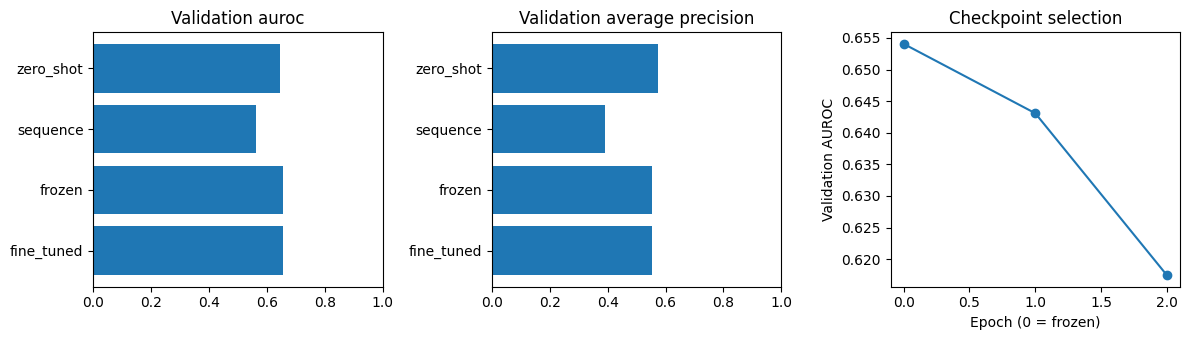

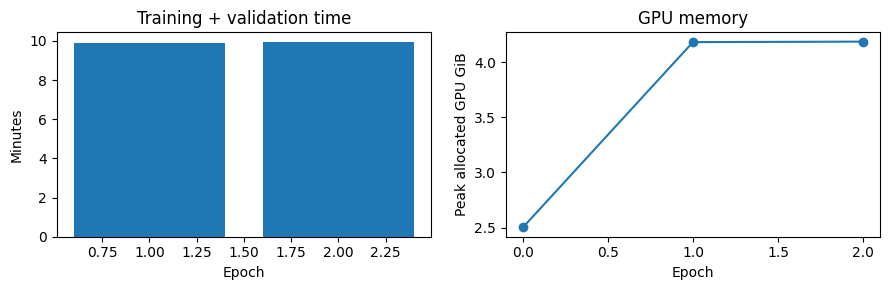

Readiness probes: 13.51 s, 4.41 GiB peak allocated GPU memory.


In [5]:
q9.show_results()

[Run protocol](results/q9/protocol.json) · [Readiness checks](results/q9/readiness.json) · [Logs](results/q9/environment/)

Verified artifacts are reused. Changed inputs, code or checkpoints require preserving the earlier run before rerunning.

Interrupted training resumes from the last completed epoch, preserving optimizer state and selection history. An incomplete epoch is repeated with the same seed. Previous logs are retained in `environment/logs/`.

## Conclusion

In [6]:
q9.show_conclusion()

The selected checkpoint changes validation AUROC by **+0.000** versus the frozen BioNeMo classifier (epoch 0). Validation guided selection; this is a development comparison, and its bootstrap intervals do not remove selection bias. No untouched test was evaluated.